---
title: "Catalog ↔ Patch bridge"
---

# Catalog ↔ Patch bridge — tiled inference across a real S2 archive

A `CatalogDomain` adapts a catalog into the `Domain` shape that
`geopatcher.SpatialPatcher` consumes. Each catalog row contributes
one sub-domain; the patcher iterates them. Pairing catalogs with
the Patcher framework is how you scale tiled inference across a
multi-file archive.

This notebook reuses the **real Sentinel-2 catalog** built in
[01_intro](01_intro.ipynb) (Lake Tahoe, June–July 2024) — eight
scenes across the same MGRS tile. The "model" is a trivial NDVI-like
rule, but the indirection it exercises is the production one:
`Catalog → CatalogDomain → SpatialPatcher.split → ApplyToChips →
Stitch` is exactly the shape a real tiled-inference pipeline takes.

In [1]:
import geocatalog as gc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from geostack import LAKE_TAHOE_BBOX, LAKE_TAHOE_TILE, load_stac_items

## 1. Reuse the catalog from `01_intro`

Same STAC discovery + URL collection as the intro — we use B04 (Red,
10 m) since it is the canonical 10 m grid the rest of the bands
resample to.

In [2]:
items = load_stac_items(
    "sentinel-2-l2a",
    LAKE_TAHOE_BBOX,
    "2024-06-01/2024-07-31",
    tile=LAKE_TAHOE_TILE,
    max_cloud_cover=15,
)
urls = [it.assets["B04"].href for it in items]
catalog = gc.build_raster_catalog(
    urls,
    filename_regex=r".*_(?P<date>\d{8})T\d{6}_.*\.tif",
    target_crs="EPSG:32610",
)
print(
    f"catalog: {len(catalog)} rows  bounds={tuple(round(x, 1) for x in catalog.total_bounds)}"
)

catalog: 22 rows  bounds=(699960.0, 4290240.0, 809760.0, 4400040.0)


## 2. `CatalogDomain` — the bridge

Wrap the catalog in a `CatalogDomain` with a chosen target
resolution. Each catalog row becomes a `GeoSlice` that downstream
consumers (the patcher or your own inference loop) iterate.

In [3]:
domain = gc.CatalogDomain(catalog=catalog, resolution=(10.0, 10.0))
print(f"len(domain): {len(domain)} sub-domains")
print(f"domain.bounds: {tuple(round(x, 1) for x in domain.bounds)}")

slices = list(domain.slices())
for i, sl in enumerate(slices[:3]):
    print(
        f"  slice {i}: bounds={tuple(round(x, 1) for x in sl.bounds)}  shape={sl.shape}"
    )
print(f"  ... ({len(slices) - 3} more)")

len(domain): 22 sub-domains
domain.bounds: (699960.0, 4290240.0, 809760.0, 4400040.0)
  slice 0: bounds=(699960.0, 4290240.0, 809760.0, 4400040.0)  shape=(10980, 10980)
  slice 1: bounds=(699960.0, 4290240.0, 809760.0, 4400040.0)  shape=(10980, 10980)
  slice 2: bounds=(699960.0, 4290240.0, 809760.0, 4400040.0)  shape=(10980, 10980)
  ... (19 more)


## 3. Tiled per-row inference loop

The canonical pattern: iterate the catalog's slices, load each,
apply your model, and store the result. This is the multi-file
equivalent of `Patcher.split + ApplyToChips` — but where the
tiling boundary is *the file boundary*, not a fixed pixel stride.

In [4]:
def water_classifier(arr: np.ndarray) -> np.ndarray:
    """Trivial 'classifier' — low NIR-band reflectance ⇒ water (class 1)."""
    # B04 (Red) DN values: low over water in summer. Threshold at 1500 DN
    # is roughly equivalent to 15 % surface reflectance.
    return (arr < 1500).astype(np.uint8)


# Restrict to a small AOI for visualisation (~2 km × 2 km, ~200 px square).
aoi_subset = gc.GeoSlice(
    bounds=(754000.0, 4324000.0, 756000.0, 4326000.0),
    interval=pd.Interval(
        pd.Timestamp("2024-06-01"), pd.Timestamp("2024-07-31"), closed="both"
    ),
    resolution=(10.0, 10.0),
    crs="EPSG:32610",
)
hits = catalog.query(aoi_subset)
print(f"AOI subset matches {len(hits)} scenes")

# Walk each matching scene, apply the classifier, accumulate.
per_scene_classifications = []
per_scene_dates = []
for _, row in hits.gdf.iterrows():
    row_slice = gc.GeoSlice(
        bounds=aoi_subset.bounds,
        interval=pd.Interval(row["start_time"], row["end_time"], closed="both"),
        resolution=aoi_subset.resolution,
        crs=aoi_subset.crs,
    )
    chip = gc.load_raster(catalog, row_slice, band_indexes=[1])
    per_scene_classifications.append(water_classifier(chip.values.squeeze()))
    per_scene_dates.append(row["start_time"].date().isoformat())
print(f"produced {len(per_scene_classifications)} per-scene classifications")

AOI subset matches 22 scenes


produced 22 per-scene classifications


## 4. Visualise per-scene predictions

Cycle through the matching scenes and plot the water-mask
classification per acquisition date.

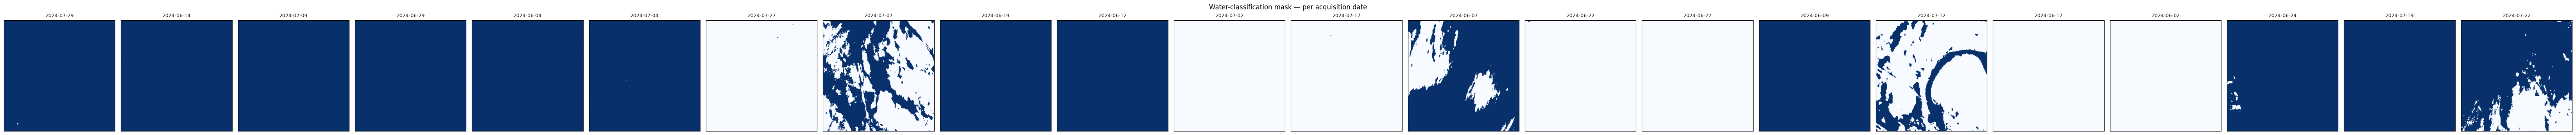

In [5]:
T = len(per_scene_classifications)
fig, axes = plt.subplots(1, T, figsize=(3.0 * T, 3.5))
for i, ax in enumerate(np.atleast_1d(axes)):
    ax.imshow(per_scene_classifications[i], cmap="Blues", vmin=0, vmax=1)
    ax.set_title(per_scene_dates[i], fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle("Water-classification mask — per acquisition date")
plt.tight_layout()
plt.show()

## 5. Same shape, expressed as a Sequential

The per-row inference loop above is the imperative version of what
in the single-raster case would be a three-op `Sequential([
GridSampler, ApplyToChips, Stitch ])`. The shapes line up exactly:

| Single raster (`RasterField`) | Multi-file archive (catalog) |
|---|---|
| `patcher.split(field)` ⇒ list of chips | `domain.slices()` ⇒ list of `GeoSlice`s |
| `op(patch.data)` per chip | `op(load_raster(catalog, slice))` per slice |
| `aggregation.merge(...)` ⇒ field | `concat` / write per-slice ⇒ archive |

In production the catalog version typically writes per-scene
predictions to S3 / GCS / a follow-up catalog rather than merging
back into one giant raster — at archive scale, the "stitch step"
*is* the catalog write.

## Why this matters

The `CatalogDomain` is the indirection that lets the same operator
pipeline work over:

- a single in-RAM raster (via `RasterField`),
- a multi-file archive (via `CatalogDomain`),
- a streaming zarr accumulator (via `RioXarrayField` over zarr),
- any future backend that implements the `Domain` Protocol.

Catalogs **are** a tiling for the Patcher framework — the bridge is
the production-ready story for "I have ten thousand Sentinel-2
scenes; run my model across all of them and stitch the per-scene
predictions into a global GeoParquet."

See also:

- [01_intro](01_intro.ipynb) — the catalog build/query/load story.
- [03_set_algebra](03_set_algebra.ipynb) — `intersect` / `union` over
  multiple catalogs (e.g. imagery × labels).
- [04_duckdb](04_duckdb.ipynb) — `DuckDBGeoCatalog` for archive-scale
  row counts (millions of rows).
- [../patching/01_intro](../patching/01_intro.ipynb) — the
  `SpatialPatcher` four-axis story for a single raster.